In [2]:
# My validation metric should use the spatial correlation metric each year
# And do the same spatial correlation metric, for each month of the year

import xarray as xr
import matplotlib.pyplot as plt
import os
import cartopy.crs as ccrs
import numpy as np
from matplotlib.colors import BoundaryNorm
import pandas as pd
from matplotlib import rcParams
import rasterio as rio
from utils import vert_interp
from string import ascii_lowercase #  'a', 'b', 'c', …


rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

# soil layer depths in ELM
zsoi = np.array([0.0071, 0.0279, 0.0623, 0.1189, 0.2122, 0.3661, 0.6198, 1.0380, 1.7276, 2.8646])
zisoi = np.array([0, 0.0175, 0.0451, 0.0906, 0.1655, 0.2891, 0.4929, 0.8289, 1.3828, 2.2961, 
                  3.8019])
dzsoi = np.array([0.0175, 0.0276, 0.0455, 0.0750, 0.1236, 0.2038, 0.3360, 0.5539, 0.9133, 1.5058])

# major cation list
cations = ['Ca2+','Mg2+','Na+','K+','Al3+']

# list of NetCDF file names generated by ELM
date_prefix = '20250427'
region = 'conus'
suffix = 'ICB20TRCNPRDCTCBC_3yearerw'
case_name = f'{date_prefix}_{region}_{suffix}'
start = 1992 # 1985
end = 2003 # 2015
file_list = [
    os.path.join(os.environ['E3SM_ROOT'], 'output',
                 case_name, 'run', f'{case_name}.elm.h1.{year}-01-01-00000.nc')
    for year in range(start, end + 1)
]
tvec = pd.date_range(f'{start}-01-01', f'{end}-12-31', freq = '1D')
tvec = tvec[(tvec.month != 2) & (tvec.month != 29)]
year_list = np.arange(start, end +1)

# path to save the graphs
path_out = os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'results', f'plot_{region}', case_name)
if not os.path.exists(path_out):
    os.mkdir(path_out)

In [3]:
hr = xr.open_dataset(file_list[0])
latixy = hr['lat'].values
longxy = hr['lon'].values
hr.close()

In [4]:
# helper function to interpolate rasterio data
def rio_interp(data, transform, height, width):
    col = np.arange(width)
    row = np.arange(height)

    lon = 360 + transform.c + (col + 0.5) * transform.a      # transform.a > 0
    lat = transform.f + (row + 0.5) * transform.e      # transform.e < 0

    # Raster is south-to-north?  Make latitude ascending for xarray.
    if lat[0] > lat[-1]:
        lat = lat[::-1]
        data = data[::-1, :]

    da = xr.DataArray(
        data,
        coords={"lat": lat, "lon": lon},
        dims=("lat", "lon"),
        name="variable",
    )

    da_regridded = da.interp(
        lat=xr.DataArray(latixy, dims="lat"),
        lon=xr.DataArray(longxy, dims="lon"),
        method="nearest"
    )

    return da_regridded

In [5]:
# SoilGrids pH - which is use for our initialization
soilgrids_ph = {}

for depth in ['0-5cm', '5-15cm', '15-30cm']:
    filename = os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'SoilGrids',
                            f'phh2o_{depth}_mean.tif')
    h = rio.open(filename)
    data = h.read(1)
    data = np.where(data == 0, np.nan, data / 10)
    transform = h.transform                    # affine transform
    height, width = h.height, h.width
    h.close()

    soilgrids_ph[depth] = rio_interp(data, transform, height, width)

In [6]:
# soil pH 0-5cm, 5-15cm, 15-30cm
# year 1992 (1 year before application starts)
hr = xr.open_mfdataset(file_list)
temp = hr['soil_pH'][0, :10, :, :].values

temp_reshape = temp.transpose(1,2,0).reshape(-1, 10)
temp_reshape_interp = vert_interp([0.025, 0.1, 0.225], zsoi, temp_reshape, False, 
                                  [0,0.05,0.15,0.30], zisoi)
temp_interp = temp_reshape_interp.reshape(temp.shape[1], temp.shape[2], 3).transpose(2,0,1)

modeled_ph = {'0-5cm': temp_interp[0, :, :], 
              '5-15cm': temp_interp[1, :, :], 
              '15-30cm': temp_interp[2, :, :]}

hr.close()

/tmp/ipykernel_146615/3188978167.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


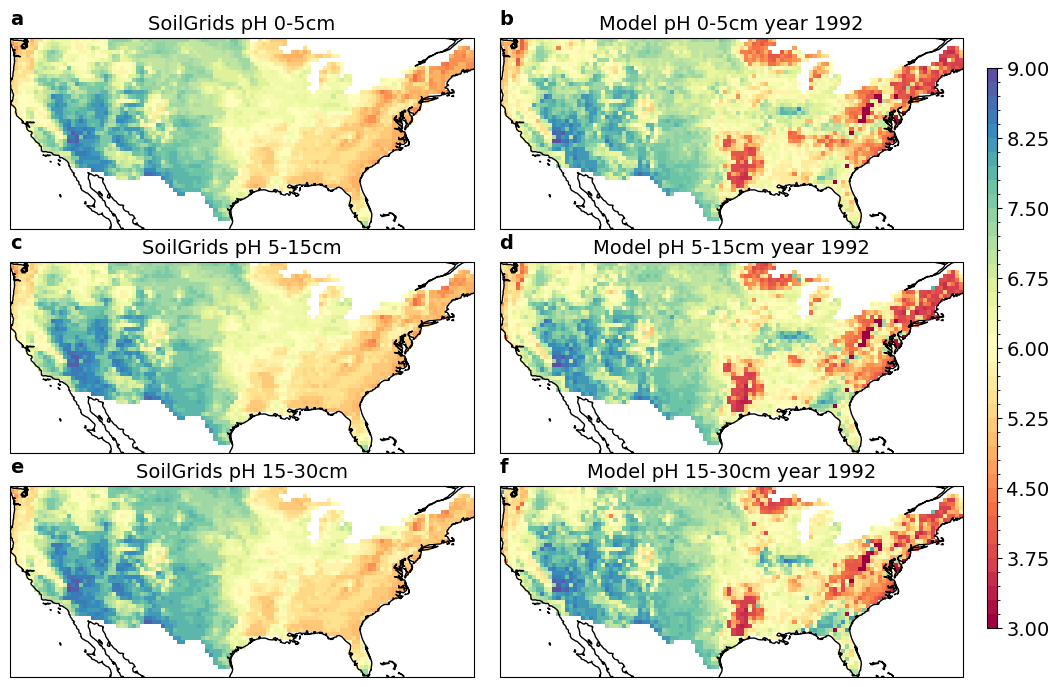

In [7]:
norm = BoundaryNorm(np.linspace(3, 9, 41), ncolors = 256, extend = 'neither')

fig, axes = plt.subplots(3, 2, figsize = (10, 7), subplot_kw = {'projection': ccrs.PlateCarree()})
for i, depth in enumerate(['0-5cm','5-15cm','15-30cm']):
    ax = axes[i, 0]
    ax.coastlines()
    # match the coverage of soilgrids to the model extent
    temp = np.where(np.isnan(modeled_ph[depth]), np.nan, soilgrids_ph[depth])
    cf = ax.pcolormesh(longxy, latixy, temp, norm = norm, cmap = 'Spectral')
    ax.set_title(f'SoilGrids pH {depth}')
    ax = axes[i, 1]
    ax.coastlines()
    ax.pcolormesh(longxy, latixy, modeled_ph[depth], norm = norm, cmap = 'Spectral')
    ax.set_title(f'Model pH {depth} year {start}')
cax = fig.add_axes([1, 0.1, 0.01, 0.8])
plt.colorbar(cf, cax = cax, orientation = 'vertical')
# add plot labels
for label, ax in zip(ascii_lowercase, axes.ravel()):
    ax.text(0, 1.07, f'{label}',
            transform=ax.transAxes, fontsize='medium', fontweight='bold')
plt.tight_layout()

/tmp/ipykernel_146615/3476678845.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


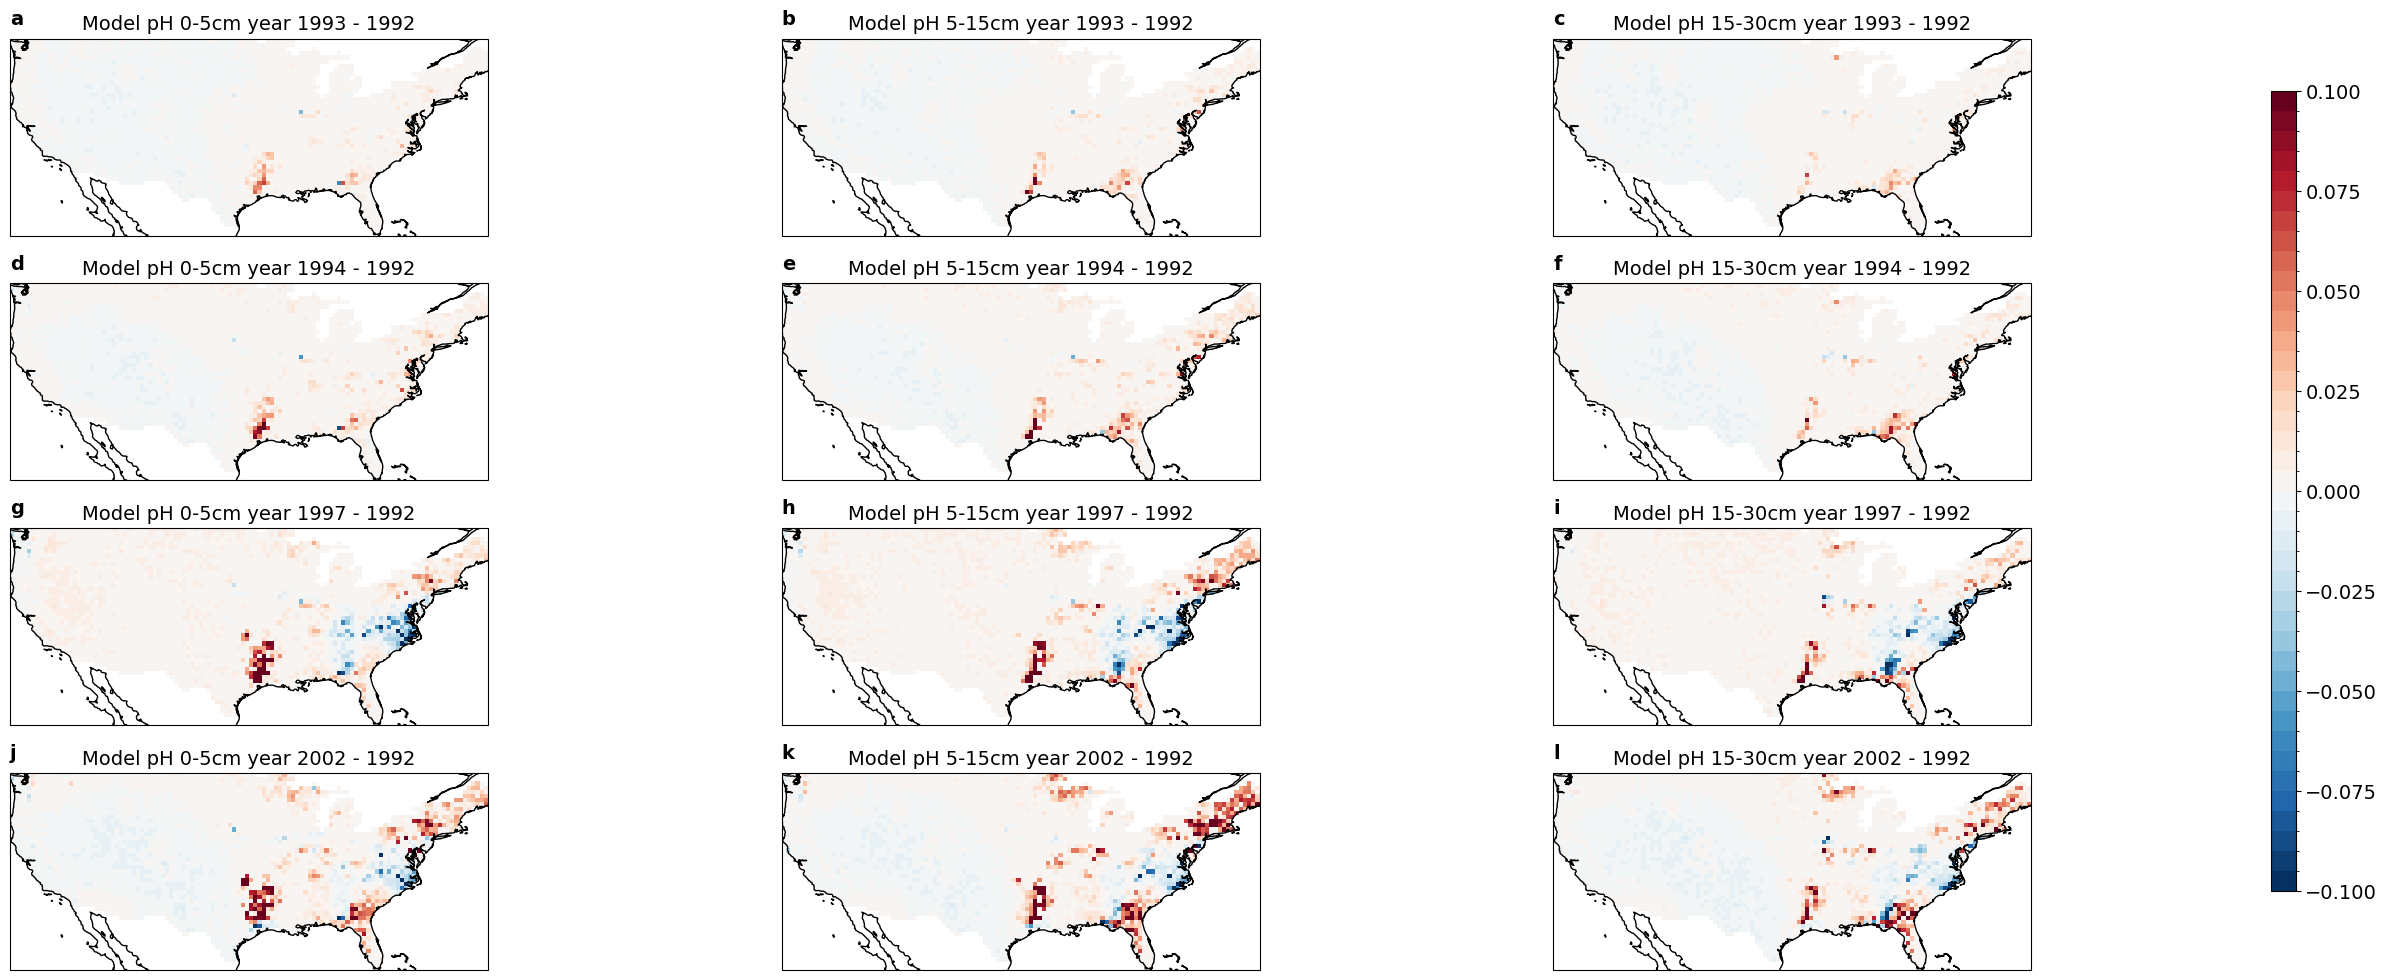

In [10]:
# Plot the soil pH 1, 2, 5, 10 years after application
norm = BoundaryNorm(np.linspace(-0.1, 0.1, 41), ncolors = 256, extend = 'neither')

fig, axes = plt.subplots(4, 3, figsize = (25, 10), subplot_kw = {'projection': ccrs.PlateCarree()})
for j, year in enumerate([1,2,5,10]):
    # soil pH 0-5cm, 5-15cm, 15-30cm
    hr = xr.open_mfdataset(file_list)
    temp = hr['soil_pH'][year, :10, :, :].values
    temp_reshape = temp.transpose(1,2,0).reshape(-1, 10)
    temp_reshape_interp = vert_interp([0.025, 0.1, 0.225], zsoi, temp_reshape, False, 
                                      [0,0.05,0.15,0.30], zisoi)
    temp_interp = temp_reshape_interp.reshape(temp.shape[1], temp.shape[2], 3).transpose(2,0,1)
    modeled_ph_year = {'0-5cm': temp_interp[0, :, :], 
                  '5-15cm': temp_interp[1, :, :], 
                  '15-30cm': temp_interp[2, :, :]}
    hr.close()

    for i, depth in enumerate(['0-5cm','5-15cm','15-30cm']):
        ax = axes[j, i]
        ax.coastlines()
        # minus year 1992 (1 year before application starts)
        cf = ax.pcolormesh(longxy, latixy, modeled_ph_year[depth] - modeled_ph[depth], 
                           norm = norm, cmap = 'RdBu_r')
        ax.set_title(f'Model pH {depth} year {start+year} - {start}')
cax = fig.add_axes([1, 0.1, 0.01, 0.8])
plt.colorbar(cf, cax = cax, orientation = 'vertical')
# add plot labels
for label, ax in zip(ascii_lowercase, axes.ravel()):
    ax.text(0, 1.07, f'{label}',
            transform=ax.transAxes, fontsize='medium', fontweight='bold')
plt.tight_layout()